### **eda data normalization**

In [2]:
import numpy as np
import pandas as pd

from sklearn import preprocessing

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
%matplotlib inline
matplotlib.style.use('ggplot')

# сгенерируем датасет из случайных чисел
df = pd.DataFrame({ 
    # Бета распределение, 5 – значение альфа, 1 – значение бета, 1000 – размер
    'beta': np.random.beta(5, 1, 1000) * 60,
    
    # Экспоненциальное распределение, 10 – "резкость" экспоненты, 1000 – размер
    'exponential': np.random.exponential(10, 1000),
    
    # Нормальное распределение, 10 – среднее значение р., 2 – стандартное отклонение, 1000 – количество сэмплов
    'normal_p': np.random.normal(10, 2, 1000),
    
    # Нормальное распределение, 10 – среднее значение р., 10 – стандартное отклонение, 1000 – количество сэмплов
    'normal_l': np.random.normal(10, 10, 1000),
})

# Копируем названия столбцов, которые теряются при использовании fit_transform()
col_names = list(df.columns)
df

,beta,exponential,normal_p,normal_l
0,39.168708,10.163727,8.605905,4.044891
1,41.530202,0.413236,8.168742,24.053417
2,55.946888,13.983105,8.884425,4.200752
3,48.335423,1.066032,12.230374,22.528078
4,29.174934,0.546599,4.622552,11.500206
...,...,...,...,...
995,44.310047,4.180946,10.480129,5.723641
996,46.254971,7.588652,9.798579,22.335277
997,58.876869,13.871607,6.719963,27.412895
998,54.694377,7.825136,10.138233,4.526875


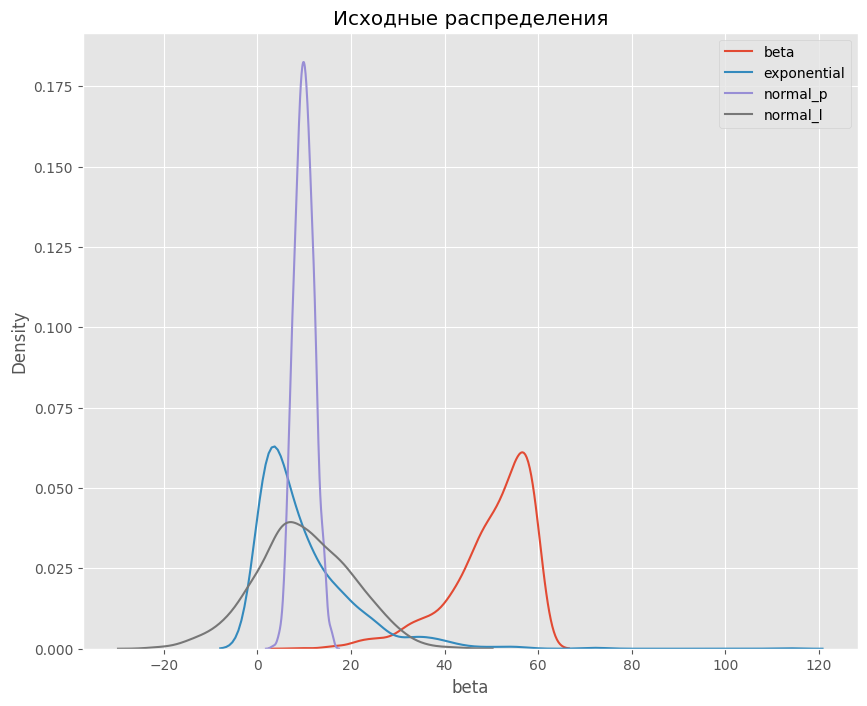

In [7]:
# зададим параметры холста, название и визуализируем кривые распределения:
fig, (ax1) = plt.subplots(ncols=1, figsize=(10, 8))
ax1.set_title('Исходные распределения')

# kdeplot() (KDE – оценка плотности ядра) – специальный метод для графиков распределений
sns.kdeplot(df['beta'], ax=ax1, label ='beta')
sns.kdeplot(df['exponential'], ax=ax1, label ='exponential')
sns.kdeplot(df['normal_p'], ax=ax1, label ='normal_p')
sns.kdeplot(df['normal_l'], ax=ax1, label ='normal_l')
plt.legend()

In [8]:
df.describe()

,beta,exponential,normal_p,normal_l
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,50.008922,10.119922,9.997211,9.971898
std,8.751966,10.551336,2.069760,10.200731
min,9.082635,0.002712,3.387237,-22.111480
25%,45.939330,2.911307,8.530537,3.531931
50%,52.221211,6.827117,9.950421,9.567468
75%,56.617291,14.007448,11.400433,16.814628
max,59.994540,112.859837,15.878165,42.586887


### **MinMaxScaler**

x_scaled = (x - x_min) / (x_max - x_min)

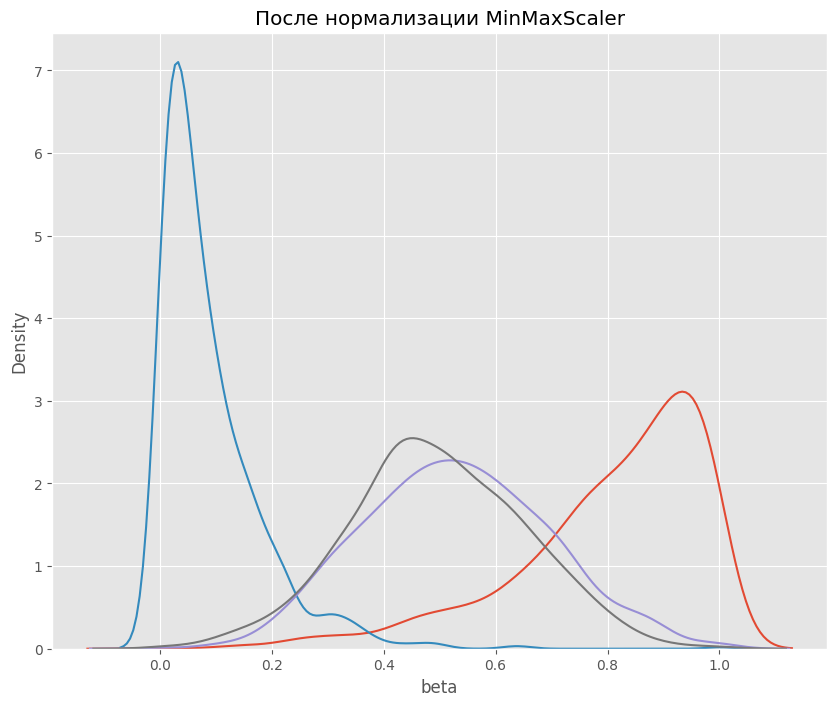

In [10]:
# инициализируем нормализатор MinMaxScaler
mm_scaler = preprocessing.MinMaxScaler()

# кодируем исходный датасет
df_mm = mm_scaler.fit_transform(df)

# Преобразуем промежуточный датасет в полноценный датафрейм для визуализации
df_mm = pd.DataFrame(df_mm, columns=col_names)

fig, (ax1) = plt.subplots(ncols=1, figsize=(10, 8))
ax1.set_title('После нормализации MinMaxScaler')

sns.kdeplot(df_mm['beta'], ax=ax1)
sns.kdeplot(df_mm['exponential'], ax=ax1)
sns.kdeplot(df_mm['normal_p'], ax=ax1)
sns.kdeplot(df_mm['normal_l'], ax=ax1);

In [12]:
df_mm.describe()

,beta,exponential,normal_p,normal_l
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.803865,0.089646,0.529182,0.495892
std,0.171904,0.093493,0.165701,0.157666
min,0.000000,0.000000,0.000000,0.000000
25%,0.723931,0.025772,0.411763,0.396353
50%,0.847318,0.060469,0.525436,0.489641
75%,0.933665,0.124093,0.641521,0.601655
max,1.000000,1.000000,1.000000,1.000000


### **RobustScaler**

x_scaled = (x - x_median) / (IQR)

IQR = Q75 - Q25

<Axes: title={'center': 'Распределения после RobustScaler'}, xlabel='beta', ylabel='Density'>

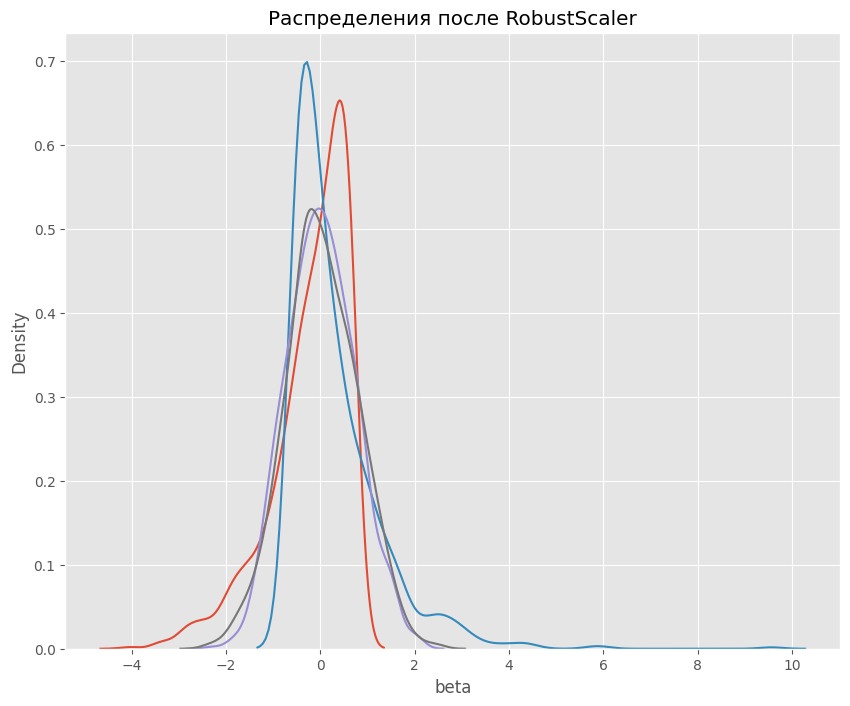

In [ ]:
# инициализируем нормализатор RobustScaler
r_scaler = preprocessing.RobustScaler()

# кодируем исходный датасет
df_r = r_scaler.fit_transform(df)

# Преобразуем промежуточный датасет в полноценный датафрейм для визуализации
df_r = pd.DataFrame(df_r, columns=col_names)

fig, (ax1) = plt.subplots(ncols=1, figsize=(10, 8))
ax1.set_title('Распределения после RobustScaler')

sns.kdeplot(df_r['beta'], ax=ax1)
sns.kdeplot(df_r['exponential'], ax=ax1)
sns.kdeplot(df_r['normal_p'], ax=ax1)
sns.kdeplot(df_r['normal_l'], ax=ax1);

In [14]:
df_r.describe()

,beta,exponential,normal_p,normal_l
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,-0.207183,0.296752,0.016304,3.044786e-02
std,0.819629,0.950901,0.721197,7.679713e-01
min,-4.039964,-0.615025,-2.286906,-2.384979e+00
25%,-0.588303,-0.352898,-0.494751,-4.543909e-01
50%,0.000000,0.000000,0.000000,6.689527e-17
75%,0.411697,0.647102,0.505249,5.456091e-01
max,0.727979,9.555820,2.065491,2.485897e+00


### **StandardScaler**

x_scaled = (x - x_mean) / (x_std)

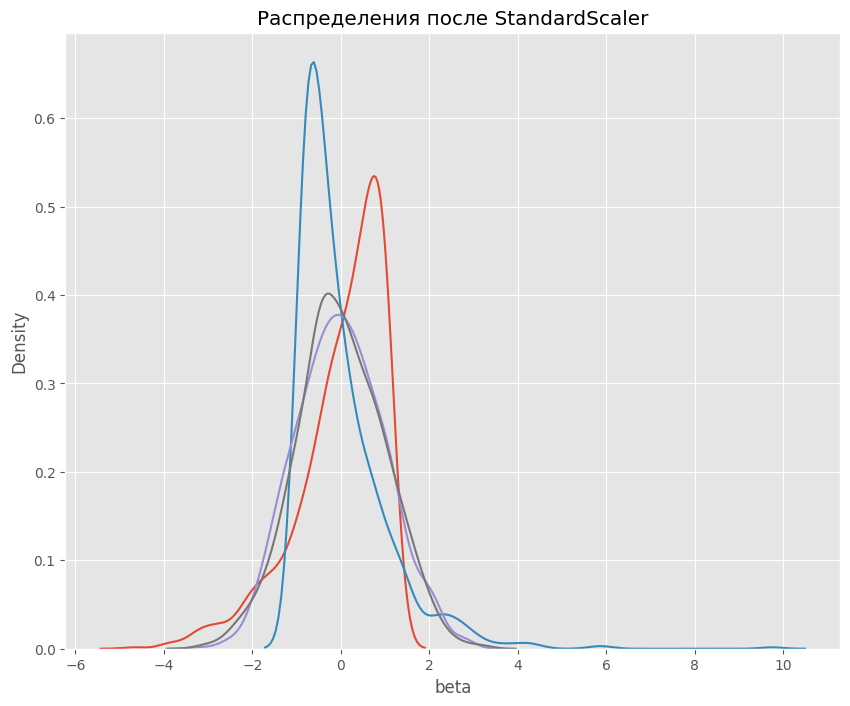

In [16]:
# инициализируем стандартизатор StandardScaler
s_scaler = preprocessing.StandardScaler()

# кодируем исходный датасет
df_s = s_scaler.fit_transform(df)

# Преобразуем промежуточный датасет в полноценный датафрейм для визуализации
df_s = pd.DataFrame(df_s, columns=col_names)

fig, (ax1) = plt.subplots(ncols=1, figsize=(10, 8))
ax1.set_title('Распределения после StandardScaler')

sns.kdeplot(df_s['beta'], ax=ax1)
sns.kdeplot(df_s['exponential'], ax=ax1)
sns.kdeplot(df_s['normal_p'], ax=ax1)
sns.kdeplot(df_s['normal_l'], ax=ax1);

In [17]:
df_s.describe()

,beta,exponential,normal_p,normal_l
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,-2.264855e-16,-6.750156e-17,1.492140e-16,3.463896e-17
std,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00
min,-4.678579e+00,-9.593357e-01,-3.195192e+00,-3.146778e+00
25%,-4.652244e-01,-6.835364e-01,-7.089750e-01,-6.316399e-01
50%,2.529028e-01,-3.122309e-01,-2.261789e-02,-3.966697e-02
75%,7.554503e-01,3.686235e-01,6.783027e-01,6.711436e-01
max,1.141528e+00,9.742019e+00,2.842792e+00,3.198919e+00


### a bit of practice

In [28]:
wine = pd.read_csv('data/wine_cleared.csv', sep=',', index_col=False)
# normlize feature price 
robust = preprocessing.RobustScaler()
wine['price_scaled'] = robust.fit_transform(wine[['price']])
print(int(wine['price_scaled'].sum()))
# standarting feature price
standart = preprocessing.StandardScaler()
wine['price_standart'] = standart.fit_transform(wine[['price']])
print(round(wine['price_standart'][129968], 2))

43501
-0.14
